In [43]:
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

from mlforecast import MLForecast
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, RNN

from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
np.random.seed(42)

In [44]:
data_path = Path("/mnt/data/PDB_Load_History_prepared.csv")
if not data_path.exists():
    data_path = Path("PDB_Load_History_prepared.csv")

df = pd.read_csv(data_path, parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df.head(), df.shape, df.dtypes

(             datetime   demand
 0 2003-03-01 00:00:00  12863.0
 1 2003-03-01 01:00:00  12389.0
 2 2003-03-01 02:00:00  12155.0
 3 2003-03-01 03:00:00  12072.0
 4 2003-03-01 04:00:00  12160.0,
 (103776, 2),
 datetime    datetime64[ns]
 demand             float64
 dtype: object)

In [45]:
# Срез только на последний 1 год данных + проверка
cutoff = df["datetime"].max() - pd.Timedelta(days=365)
df_1y = df.loc[df["datetime"] > cutoff].copy().reset_index(drop=True)

check = {
    "start": df_1y["datetime"].min(),
    "end": df_1y["datetime"].max(),
    "rows": len(df_1y),
    "span_days": (df_1y["datetime"].max() - df_1y["datetime"].min()).days,
}
print(check)

assert df_1y["datetime"].min() > cutoff
assert df_1y["datetime"].is_monotonic_increasing
assert df_1y["demand"].notna().all()

df_1y.head()

{'start': Timestamp('2014-01-01 00:00:00'), 'end': Timestamp('2014-12-31 23:00:00'), 'rows': 8760, 'span_days': 364}


,datetime,demand
0,2014-01-01 00:00:00,13821.0
1,2014-01-01 01:00:00,13280.0
2,2014-01-01 02:00:00,12885.0
3,2014-01-01 03:00:00,12729.0
4,2014-01-01 04:00:00,12779.0


In [46]:
ml_df = df_1y.rename(columns={"datetime": "ds", "demand": "y"}).copy()
ml_df["unique_id"] = "load"
ml_df = ml_df[["unique_id", "ds", "y"]]

h = 168
n_windows = 3
step_size = 168

train_end = ml_df["ds"].max() - pd.Timedelta(hours=h * n_windows)
train_df = ml_df.loc[ml_df["ds"] <= train_end].copy()
test_df = ml_df.loc[ml_df["ds"] > train_end].copy()

print("train:", train_df.shape, train_df["ds"].min(), train_df["ds"].max())
print("test :", test_df.shape, test_df["ds"].min(), test_df["ds"].max())

train: (8256, 3) 2014-01-01 00:00:00 2014-12-10 23:00:00
test : (504, 3) 2014-12-11 00:00:00 2014-12-31 23:00:00


In [47]:
def metric_table(cv_df, model_cols):
    rows = []
    y_true = cv_df["y"].to_numpy()
    for col in model_cols:
        y_pred = cv_df[col].to_numpy()
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
        rows.append({"model": col, "RMSE": rmse, "MAE": mae, "MAPE_%": mape})
    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

In [48]:
ml_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

fcst = MLForecast(
    models=ml_models,
    freq="H",
    lags=[1, 24, 48, 168],
    date_features=["hour", "dayofweek", "month"],
    num_threads=1,
)

ml_cv = fcst.cross_validation(
    df=train_df,
    h=h,
    n_windows=n_windows,
    step_size=step_size,
    refit=True,
)

ml_metrics = metric_table(ml_cv, list(ml_models.keys()))
ml_metrics

c:\games\!!!studyMaga\2026\AVR\ELECTRODEMAND\.venv\lib\site-packages\utilsforecast\processing.py:406: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\games\!!!studyMaga\2026\AVR\ELECTRODEMAND\.venv\lib\site-packages\utilsforecast\processing.py:406: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\games\!!!studyMaga\2026\AVR\ELECTRODEMAND\.venv\lib\site-packages\utilsforecast\processing.py:406: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\games\!!!studyMaga\2026\AVR\ELECTRODEMAND\.venv\lib\site-packages\utilsforecast\processing.py:406: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\games

,model,RMSE,MAE,MAPE_%
0,RandomForest,1095.874445,858.195516,5.925188
1,LinearRegression,1618.947141,1285.573245,9.446180
2,Ridge,1618.947799,1285.575318,9.446191


In [49]:
dl_models = [
    NBEATS(h=h, input_size=2*h, max_steps=50, scaler_type="standard"),
    NHITS(h=h, input_size=2*h, max_steps=50, scaler_type="standard"),
    RNN(h=h, input_size=2*h, max_steps=50, scaler_type="standard"),
]

nf = NeuralForecast(models=dl_models, freq="H")
dl_cv = nf.cross_validation(
    df=train_df,
    n_windows=n_windows,
    step_size=step_size,
    val_size=h,
)

dl_model_cols = [c for c in dl_cv.columns if c not in ["unique_id", "ds", "cutoff", "y"]]
dl_metrics = metric_table(dl_cv, dl_model_cols)
dl_metrics

Seed set to 1
Seed set to 1
Seed set to 1
c:\games\!!!studyMaga\2026\AVR\ELECTRODEMAND\.venv\lib\site-packages\neuralforecast\common\_base_model.py:602: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.7 M  | train
-------------------------------------------------------
3.5 M     Trainable params
169 K     Non-trainable params
3.7 M     Total params
14.623    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

c:\games\!!!studyMaga\2026\AVR\ELECTRODEMAND\.venv\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  9.66it/s, v_num=18, train_loss_step=0.317, train_loss_epoch=0.317, valid_loss=981.0]

`Trainer.fit` stopped: `max_steps=50` reached.


...

`Trainer.fit` stopped: `max_steps=50` reached.


Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s, v_num=22, train_loss_step=0.359, train_loss_epoch=0.359, valid_loss=1.03e+3]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 83.34it/s]


,model,RMSE,MAE,MAPE_%
0,NBEATS,1097.011497,845.991864,5.793869
1,NHITS,1103.024472,833.823105,5.755837
2,RNN,1223.466019,967.937733,6.722606


In [50]:
results = pd.concat([
    ml_metrics.assign(group="ML"),
    dl_metrics.assign(group="DL"),
], ignore_index=True)

results = results.sort_values(["RMSE", "MAE"]).reset_index(drop=True)
results

,model,RMSE,MAE,MAPE_%,group
0,RandomForest,1095.874445,858.195516,5.925188,ML
1,NBEATS,1097.011497,845.991864,5.793869,DL
2,NHITS,1103.024472,833.823105,5.755837,DL
3,RNN,1223.466019,967.937733,6.722606,DL
4,LinearRegression,1618.947141,1285.573245,9.446180,ML
5,Ridge,1618.947799,1285.575318,9.446191,ML


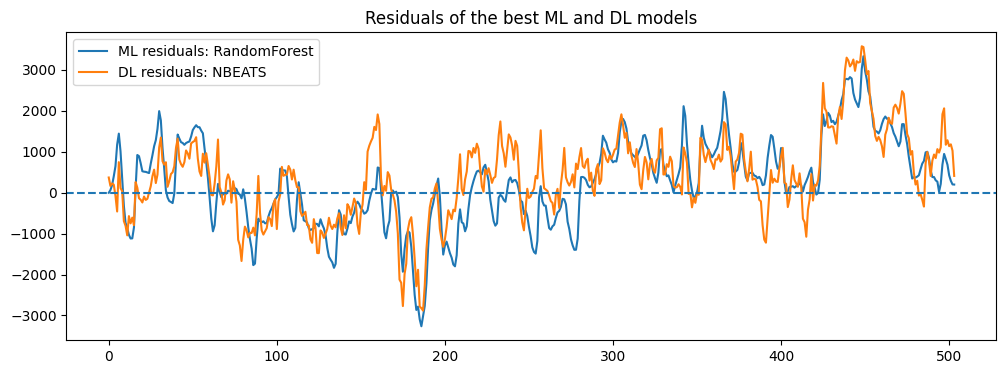

ML Ljung-Box p-value:
        lb_stat  lb_pvalue
24  4708.851958        0.0

DL Ljung-Box p-value:
        lb_stat  lb_pvalue
24  3446.180184        0.0


In [51]:
# Остатки и проверка их структуры для лучших ML и DL моделей
best_ml = ml_metrics.iloc[0]["model"]
best_dl = dl_metrics.iloc[0]["model"]

ml_resid = ml_cv["y"] - ml_cv[best_ml]
dl_resid = dl_cv["y"] - dl_cv[best_dl]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ml_resid.reset_index(drop=True), label=f"ML residuals: {best_ml}")
ax.plot(dl_resid.reset_index(drop=True), label=f"DL residuals: {best_dl}")
ax.axhline(0, linestyle="--")
ax.legend()
ax.set_title("Residuals of the best ML and DL models")
plt.show()

print("ML Ljung-Box p-value:")
print(acorr_ljungbox(ml_resid.dropna(), lags=[24], return_df=True))
print("\nDL Ljung-Box p-value:")
print(acorr_ljungbox(dl_resid.dropna(), lags=[24], return_df=True))


In [52]:
anom_df = df_1y.copy().reset_index(drop=True)
anom_df["demand_orig"] = anom_df["demand"].copy()
anom_df["demand_anom"] = anom_df["demand"].copy()

std = anom_df["demand"].std()
rng = np.random.default_rng(42)
anomaly_positions = rng.choice(np.arange(24, len(anom_df) - 24), size=8, replace=False)

for pos in anomaly_positions:
    sign = rng.choice([1, -1])
    magnitude = 4 * std + rng.uniform(0, 2 * std)
    anom_df.loc[pos, "demand_anom"] = max(
        0,
        anom_df.loc[pos, "demand"] + sign * magnitude,
    )
    for offset in (-1, 1):
        idx = pos + offset
        if 0 <= idx < len(anom_df):
            anom_df.loc[idx, "demand_anom"] = max(
                0,
                anom_df.loc[idx, "demand"] + sign * 1.5 * std,
            )

anom_df["demand_anom"] = anom_df["demand_anom"].clip(lower=0)

injected_positions = sorted(
    set(
        list(anomaly_positions)
        + [pos + offset for pos in anomaly_positions for offset in (-1, 1)]
    )
)
anom_df["true_anomaly"] = False
anom_df.loc[injected_positions, "true_anomaly"] = True
anom_df["demand"] = anom_df["demand_anom"]

print("Injected anomalies at positions:", sorted(anomaly_positions))
print("True anomaly positions (including adjacent injected points):", injected_positions)
anom_df.head()

Injected anomalies at positions: [772, 800, 3795, 3845, 5723, 6099, 6762, 7502]
True anomaly positions (including adjacent injected points): [771, 772, 773, 799, 800, 801, 3794, 3795, 3796, 3844, 3845, 3846, 5722, 5723, 5724, 6098, 6099, 6100, 6761, 6762, 6763, 7501, 7502, 7503]


,datetime,demand,demand_orig,demand_anom,true_anomaly
0,2014-01-01 00:00:00,13821.0,13821.0,13821.0,False
1,2014-01-01 01:00:00,13280.0,13280.0,13280.0,False
2,2014-01-01 02:00:00,12885.0,12885.0,12885.0,False
3,2014-01-01 03:00:00,12729.0,12729.0,12729.0,False
4,2014-01-01 04:00:00,12779.0,12779.0,12779.0,False


In [53]:
anom_df["ds"] = anom_df["datetime"]
anom_df["y"] = anom_df["demand"]

stl = STL(anom_df["y"], period=168, robust=True).fit()
resid = stl.resid
mad = np.median(np.abs(resid - np.median(resid))) + 1e-8
robust_z = 0.6745 * (resid - np.median(resid)) / mad
anom_df["anom_stl"] = np.abs(robust_z) > 3.5

feat = anom_df[["y"]].copy()
feat["lag_1"] = feat["y"].shift(1)
feat["lag_24"] = feat["y"].shift(24)
feat["lag_168"] = feat["y"].shift(168)
feat["roll_mean_24"] = feat["y"].rolling(24).mean()
feat["roll_std_24"] = feat["y"].rolling(24).std()
feat["hour"] = anom_df["ds"].dt.hour
feat["dow"] = anom_df["ds"].dt.dayofweek
feat = feat.dropna().copy()

scaler = StandardScaler()
X = scaler.fit_transform(feat)
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
feat["anom_iforest"] = iso.fit_predict(X) == -1

lof = LocalOutlierFactor(n_neighbors=35, contamination=0.01)
feat["anom_lof"] = lof.fit_predict(X) == -1

anom_df = anom_df.merge(feat[["anom_iforest", "anom_lof"]], left_index=True, right_index=True, how="left")
anom_summary = pd.DataFrame({
    "method": ["STL robust z-score", "IsolationForest", "LocalOutlierFactor"],
    "anomaly_count": [
        int(anom_df["anom_stl"].sum()),
        int(anom_df["anom_iforest"].fillna(False).sum()),
        int(anom_df["anom_lof"].fillna(False).sum()),
    ],
})
anom_summary

C:\Users\Александр\AppData\Local\Temp\ipykernel_19892\1198673105.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  int(anom_df["anom_iforest"].fillna(False).sum()),
C:\Users\Александр\AppData\Local\Temp\ipykernel_19892\1198673105.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  int(anom_df["anom_lof"].fillna(False).sum()),


,method,anomaly_count
0,STL robust z-score,1146
1,IsolationForest,86
2,LocalOutlierFactor,86


In [54]:
# Согласованность методов аномалий
anom_points = anom_df.loc[
    anom_df["anom_stl"].fillna(False)
    | anom_df["anom_iforest"].fillna(False)
    | anom_df["anom_lof"].fillna(False),
    ["datetime", "demand", "anom_stl", "anom_iforest", "anom_lof"]
].copy()

anom_points["votes"] = (
    anom_points[["anom_stl", "anom_iforest", "anom_lof"]]
    .fillna(False)
    .astype(int)
    .sum(axis=1)
)

anom_points = anom_points.sort_values(["votes", "datetime"], ascending=[False, True]).reset_index(drop=True)
anom_points.head(20)

C:\Users\Александр\AppData\Local\Temp\ipykernel_19892\2002373726.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | anom_df["anom_iforest"].fillna(False)
C:\Users\Александр\AppData\Local\Temp\ipykernel_19892\2002373726.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | anom_df["anom_lof"].fillna(False),
C:\Users\Александр\AppData\Local\Temp\ipykernel_19892\2002373726.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To op

,datetime,demand,anom_stl,anom_iforest,anom_lof,votes
0,2014-06-08 04:00:00,5700.230690,True,True,True,3
1,2014-09-03 11:00:00,18882.000000,True,True,True,3
2,2014-02-02 03:00:00,7004.230690,True,False,True,2
3,2014-02-02 04:00:00,0.000000,True,False,True,2
4,2014-02-02 05:00:00,7313.230690,True,False,True,2
5,2014-02-03 08:00:00,27147.432716,True,False,True,2
6,2014-02-03 09:00:00,20445.769310,True,False,True,2
7,2014-06-08 02:00:00,6056.230690,True,False,True,2
8,2014-06-08 03:00:00,0.000000,True,False,True,2
9,2014-06-09 00:00:00,11574.000000,True,False,True,2


C:\Users\Александр\AppData\Local\Temp\ipykernel_19892\1340271468.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = anom_df[col].fillna(False)


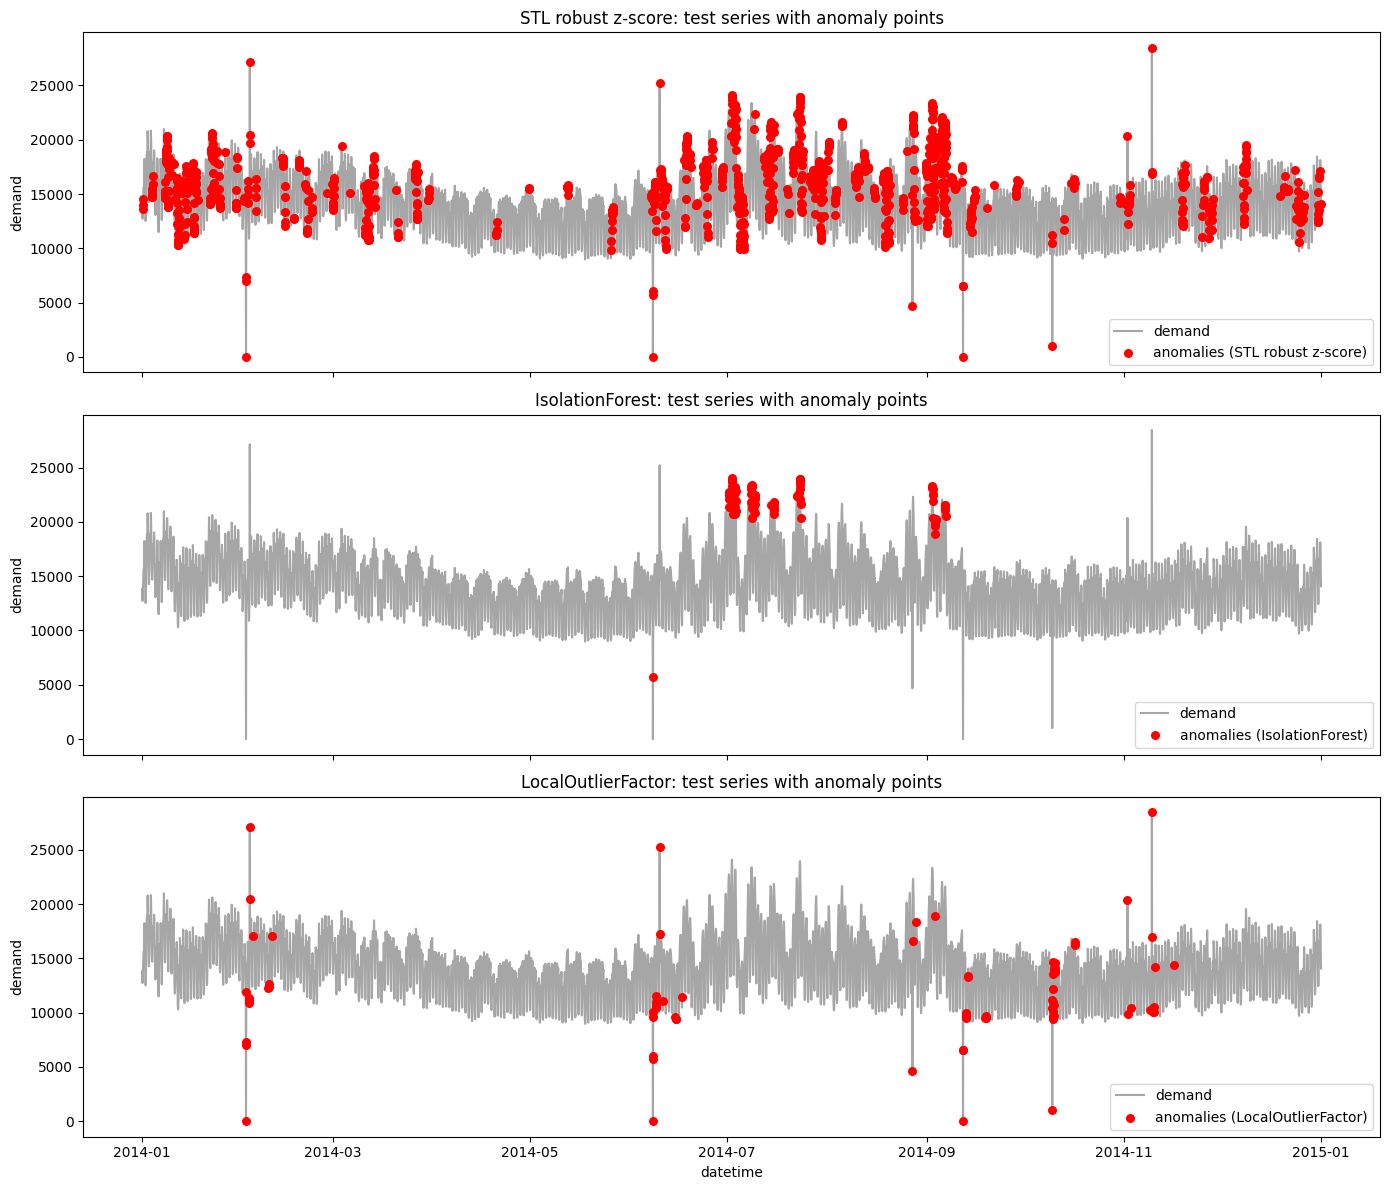

In [55]:
# Графики тестового ряда с точками аномалий для каждого метода
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
methods = [
    ("STL robust z-score", "anom_stl"),
    ("IsolationForest", "anom_iforest"),
    ("LocalOutlierFactor", "anom_lof"),
]

for ax, (label, col) in zip(axes, methods):
    ax.plot(anom_df["datetime"], anom_df["demand"], color="gray", alpha=0.7, label="demand")
    mask = anom_df[col].fillna(False)
    ax.scatter(
        anom_df.loc[mask, "datetime"],
        anom_df.loc[mask, "demand"],
        color="red",
        s=30,
        label=f"anomalies ({label})",
        zorder=3,
    )
    ax.set_title(f"{label}: test series with anomaly points")
    ax.set_ylabel("demand")
    ax.legend()

axes[-1].set_xlabel("datetime")
plt.tight_layout()
plt.show()

In [56]:
# Проверка, какие искусственные аномалии были найдены, а какие пропущены
truth_df = anom_df.loc[anom_df["true_anomaly"], ["datetime", "demand", "demand_orig", "true_anomaly"]].copy()
for method in ["anom_stl", "anom_iforest", "anom_lof"]:
    truth_df[method] = anom_df.loc[truth_df.index, method].values

summary = []
for method in ["anom_stl", "anom_iforest", "anom_lof"]:
    found = truth_df[method].sum()
    total = len(truth_df)
    missed = total - found
    false_positives = int(
        anom_df.loc[~anom_df["true_anomaly"], method].sum()
    )
    summary.append({
        "method": method,
        "found_true_anomalies": int(found),
        "missed_true_anomalies": int(missed),
        "false_positives": false_positives,
    })

print("Injected anomaly detection summary:")
print(pd.DataFrame(summary))


Injected anomaly detection summary:
         method  found_true_anomalies  missed_true_anomalies  false_positives
0      anom_stl                    23                      1             1123
1  anom_iforest                     1                     23               85
2      anom_lof                    20                      4               66
